# Batch EP tomography → ρ₁₁ decoherence analysis

Runs the same pipeline as `view_single_raw.ipynb` over every `ds_raw.h5`
discovered under a root folder. For each file we also load `node.json`
from the same subfolder and store `driving_amp_ratio` so it can be used
as an x-axis variable in cross-file plots.

```
all_results[h5_path] = {
    'driving_amp_ratio': float | None,
    'node_json': dict | None,
    'results': [
        {'qubit_name', 'sq_data', 'rho_ds',
         'hankel', 'mdo', 'decoh', 'decoh_guesses'},
        ...
    ],
}
```

Plotting is intentionally not packaged — reuse the plotting cells from
`view_single_raw.ipynb` against any single entry in `all_results` as needed.

In [1]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt

from scqat.workflows.ep_pipeline import analyze_file
from scqat.workflows.ep_plotting import make_figures, save_figures

In [2]:
# Discover all ds_raw.h5 files under a root folder.
# The expected layout is:
#   <root>/<#NNNN_..._LCH_qubit_parametric_drive_time_tomo_..._HHMMSS>/ds_raw.h5
#   <root>/<...same subfolder...>/node.json
root_folder = r'/Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180'
subfolder_pattern = 'LCH_qubit_parametric_drive_time_tomo'

if not os.path.isdir(root_folder):
    raise FileNotFoundError(f'Root folder not found: {root_folder}')

h5_file_paths = []
for entry in sorted(os.listdir(root_folder)):
    sub = os.path.join(root_folder, entry)
    if not os.path.isdir(sub):
        continue
    if subfolder_pattern not in entry:
        continue
    h5 = os.path.join(sub, 'ds_raw.h5')
    if not os.path.isfile(h5):
        print(f'  [skip] no ds_raw.h5 in {entry}')
        continue
    h5_file_paths.append(h5)

if not h5_file_paths:
    raise RuntimeError(f'No matching subfolders with ds_raw.h5 found under {root_folder}')

print(f'{len(h5_file_paths)} file(s) discovered:')
for p in h5_file_paths:
    print(f'  - {os.path.basename(os.path.dirname(p))}')

15 file(s) discovered:
  - #1508_LCH_qubit_parametric_drive_time_tomo_0_224304
  - #1509_LCH_qubit_parametric_drive_time_tomo_1_225238
  - #1510_LCH_qubit_parametric_drive_time_tomo_2_230213
  - #1511_LCH_qubit_parametric_drive_time_tomo_3_231147
  - #1512_LCH_qubit_parametric_drive_time_tomo_4_232122
  - #1513_LCH_qubit_parametric_drive_time_tomo_5_233056
  - #1514_LCH_qubit_parametric_drive_time_tomo_6_234031
  - #1515_LCH_qubit_parametric_drive_time_tomo_7_235006
  - #1516_LCH_qubit_parametric_drive_time_tomo_8_235940
  - #1517_LCH_qubit_parametric_drive_time_tomo_9_000914
  - #1518_LCH_qubit_parametric_drive_time_tomo_10_001849
  - #1519_LCH_qubit_parametric_drive_time_tomo_11_002823
  - #1520_LCH_qubit_parametric_drive_time_tomo_12_003758
  - #1521_LCH_qubit_parametric_drive_time_tomo_13_004732
  - #1522_LCH_qubit_parametric_drive_time_tomo_14_005707


In [3]:
# Run the full pipeline on each file. For every file, also load node.json from the same
# folder and store driving_amp_ratio alongside the per-qubit results.
# Figures (the same ones shown in view_single_raw.ipynb) are generated per qubit and
# saved into a 'figures/' subfolder next to ds_raw.h5.
#
# all_results[path] = {
#     'driving_amp_ratio': float | None,
#     'node_json': dict | None,        # full contents (for ad-hoc lookups later)
#     'results': list[dict],            # per-qubit pipeline output (see analyze_file)
#     'figure_dir': str,                # folder where figures were saved
# }
SAVE_FIGURES = True
FIGURES_SUBDIR = 'figures'

all_results = {}
for path in h5_file_paths:
    folder = os.path.dirname(path)
    tag = os.path.basename(folder)
    print(f'\n=== {tag} ===')

    node_json_path = os.path.join(folder, 'node.json')
    node_json = None
    amp_ratio = None
    if os.path.isfile(node_json_path):
        with open(node_json_path, 'r', encoding='utf-8') as f:
            node_json = json.load(f)
        try:
            amp_ratio = float(node_json['data']['parameters']['model']['driving_amp_ratio'])
        except (KeyError, TypeError, ValueError) as exc:
            print(f'  [warn] could not read driving_amp_ratio from node.json ({exc})')
    else:
        print(f'  [warn] node.json not found in {folder}')

    per_file_results = analyze_file(path)

    figure_dir = os.path.join(folder, FIGURES_SUBDIR)
    if SAVE_FIGURES:
        n_saved = 0
        for r in per_file_results:
            figs = make_figures(r)
            saved = save_figures(figs, figure_dir)
            n_saved += len(saved)
            for fig in figs.values():
                plt.close(fig)
        print(f'  saved {n_saved} figure(s) to {figure_dir}')

    all_results[path] = {
        'driving_amp_ratio': amp_ratio,
        'node_json': node_json,
        'results': per_file_results,
        'figure_dir': figure_dir,
    }
    print(f'  driving_amp_ratio = {amp_ratio}')

print(f'\nDone. Analyzed {len(all_results)} file(s).')


=== #1508_LCH_qubit_parametric_drive_time_tomo_0_224304 ===
[q1] freqs=11  hankel_seeded=11  mdo_ok=11  decoh_ok=11
  saved 9 figure(s) to /Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1508_LCH_qubit_parametric_drive_time_tomo_0_224304/figures
  driving_amp_ratio = 0.75

=== #1509_LCH_qubit_parametric_drive_time_tomo_1_225238 ===
[q1] freqs=11  hankel_seeded=11  mdo_ok=11  decoh_ok=11
  saved 9 figure(s) to /Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1509_LCH_qubit_parametric_drive_time_tomo_1_225238/figures
  driving_amp_ratio = 0.8

=== #1510_LCH_qubit_parametric_drive_time_tomo_2_230213 ===
[q1] freqs=11  hankel_seeded=11  mdo_ok=11  decoh_ok=11
  saved 9 figure(s) to /Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1510_LCH_qubit_parametric_drive_time_tomo_2_230213/figures
  driving_amp_ratio = 0.85

=== #15

In [4]:
# Quick cross-file summary table.
for path, entry in all_results.items():
    tag = os.path.basename(os.path.dirname(path))
    amp = entry['driving_amp_ratio']
    for r in entry['results']:
        n_freq = r['rho_ds'].sizes.get('driving_frequency', 0)
        n_mdo_ok = sum(1 for v in r['mdo'].values() if v is not None and v.get('success'))
        n_decoh_ok = sum(1 for v in r['decoh'].values() if v is not None)
        print(f'[{tag}] amp={amp}  {r["qubit_name"]}: freqs={n_freq}  mdo_ok={n_mdo_ok}  decoh_ok={n_decoh_ok}')

[#1508_LCH_qubit_parametric_drive_time_tomo_0_224304] amp=0.75  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1509_LCH_qubit_parametric_drive_time_tomo_1_225238] amp=0.8  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1510_LCH_qubit_parametric_drive_time_tomo_2_230213] amp=0.85  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1511_LCH_qubit_parametric_drive_time_tomo_3_231147] amp=0.9  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1512_LCH_qubit_parametric_drive_time_tomo_4_232122] amp=0.95  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1513_LCH_qubit_parametric_drive_time_tomo_5_233056] amp=1.0  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1514_LCH_qubit_parametric_drive_time_tomo_6_234031] amp=1.05  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1515_LCH_qubit_parametric_drive_time_tomo_7_235006] amp=1.1  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1516_LCH_qubit_parametric_drive_time_tomo_8_235940] amp=1.15  q1: freqs=11  mdo_ok=11  decoh_ok=11
[#1517_LCH_qubit_parametric_drive_time_tomo_9_000914] amp=1.2  q1: freqs=11  mdo_ok=11  decoh_o

In [5]:
# --- Cross-file plots vs driving_amp_ratio ---
# For each (file, qubit) pick:
#   - best_freq_mdo  = driving_frequency with the smallest MDO chisqr
#   - best_freq_dec  = driving_frequency with the smallest decoherence chisqr
# Then plot:
#   (1) best_freq_mdo and best_freq_dec   vs amp_ratio
#   (2) MDO mode parameters (a, k, f) at best_freq_mdo  vs amp_ratio (one dot per mode)
#   (3) decoherence (gamma, lambda_, Delta) at best_freq_dec  vs amp_ratio


def _best_freq(per_freq):
    valid = [(f, r) for f, r in per_freq.items()
             if r is not None and np.isfinite(r.get('chisqr', np.inf))]
    if not valid:
        return None, None
    f_val, res = min(valid, key=lambda x: x[1]['chisqr'])
    return float(f_val), res


# Aggregate: agg[qubit_name] = list of dict per file (sorted by amp_ratio at the end)
agg = {}
for path, entry in all_results.items():
    amp = entry['driving_amp_ratio']
    if amp is None:
        continue
    for r in entry['results']:
        qname = r['qubit_name']
        f_mdo, res_mdo = _best_freq(r['mdo'])
        f_dec, res_dec = _best_freq(r['decoh'])
        agg.setdefault(qname, []).append({
            'amp': amp,
            'f_mdo': f_mdo,
            'res_mdo': res_mdo,
            'f_dec': f_dec,
            'res_dec': res_dec,
        })


for qname, rows in agg.items():
    rows.sort(key=lambda d: d['amp'])



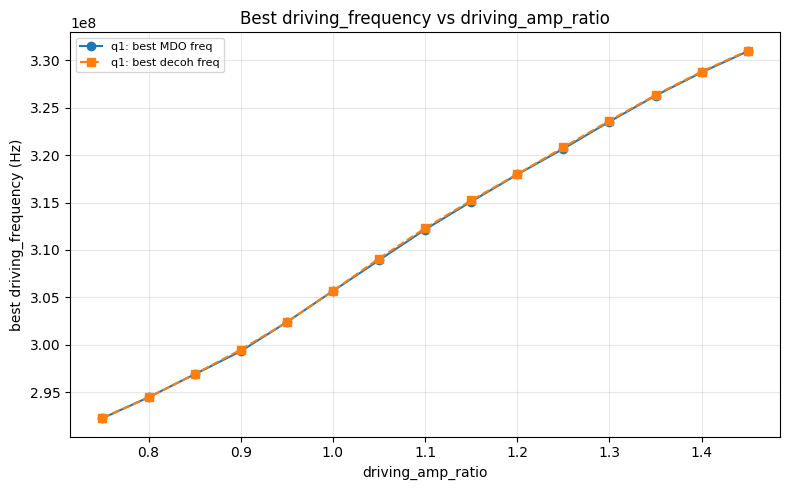

In [6]:
# --- (1) Best driving_frequency vs amp_ratio ---
fig1, ax1 = plt.subplots(figsize=(8, 5))
for qname, rows in agg.items():
    amps = [d['amp'] for d in rows]
    f_mdo = [d['f_mdo'] for d in rows]
    f_dec = [d['f_dec'] for d in rows]
    ax1.plot(amps, f_mdo, 'o-', label=f'{qname}: best MDO freq')
    ax1.plot(amps, f_dec, 's--', label=f'{qname}: best decoh freq')
ax1.set_xlabel('driving_amp_ratio')
ax1.set_ylabel('best driving_frequency (Hz)')
ax1.set_title('Best driving_frequency vs driving_amp_ratio')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8)
fig1.tight_layout()
plt.show()




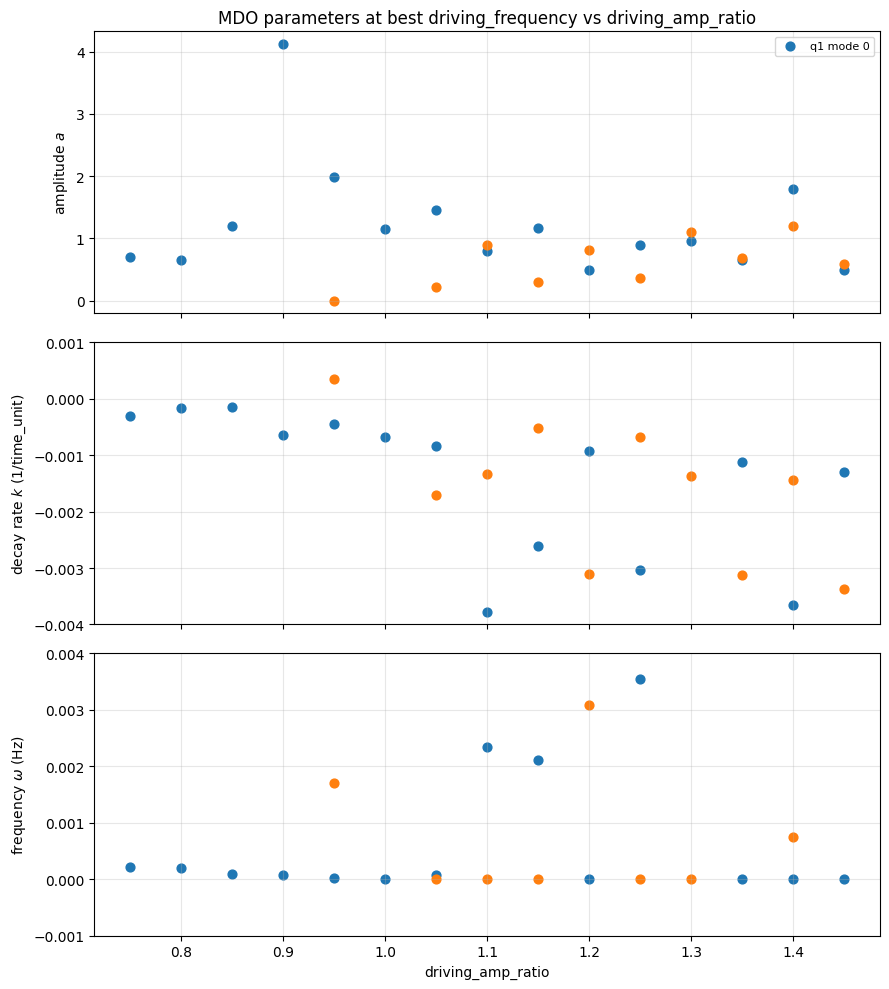

In [16]:
# --- (2) MDO mode params (a, k, f) at best_freq_mdo vs amp_ratio ---
fig2, axes2 = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
for q_idx, (qname, rows) in enumerate(agg.items()):
    marker = 'osDv^P*X'[q_idx % 8]
    for d in rows:
        res = d['res_mdo']
        if res is None:
            continue
        for k, m in enumerate(res['modes']):
            color = f'C{k}'
            lbl = f'{qname} mode {k}' if d is rows[0] else None
            axes2[0].scatter(d['amp'], m['a'], color=color, marker=marker, s=40, label=lbl)
            axes2[1].scatter(d['amp'], m['k'], color=color, marker=marker, s=40, label=lbl)
            axes2[2].scatter(d['amp'], m['f']*2*np.pi, color=color, marker=marker, s=40, label=lbl)
axes2[0].set_ylabel('amplitude $a$')
axes2[0].set_title('MDO parameters at best driving_frequency vs driving_amp_ratio')
axes2[0].grid(True, alpha=0.3)
axes2[0].legend(fontsize=8, loc='best')
axes2[1].set_ylabel('decay rate $k$ (1/time_unit)')
axes2[1].set_ylim(-0.004, 0.001)
axes2[1].grid(True, alpha=0.3)
axes2[2].set_ylabel('frequency $\omega$ (Hz)')
axes2[2].set_ylim(-0.001, 0.004)
axes2[2].set_xlabel('driving_amp_ratio')
axes2[2].grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()


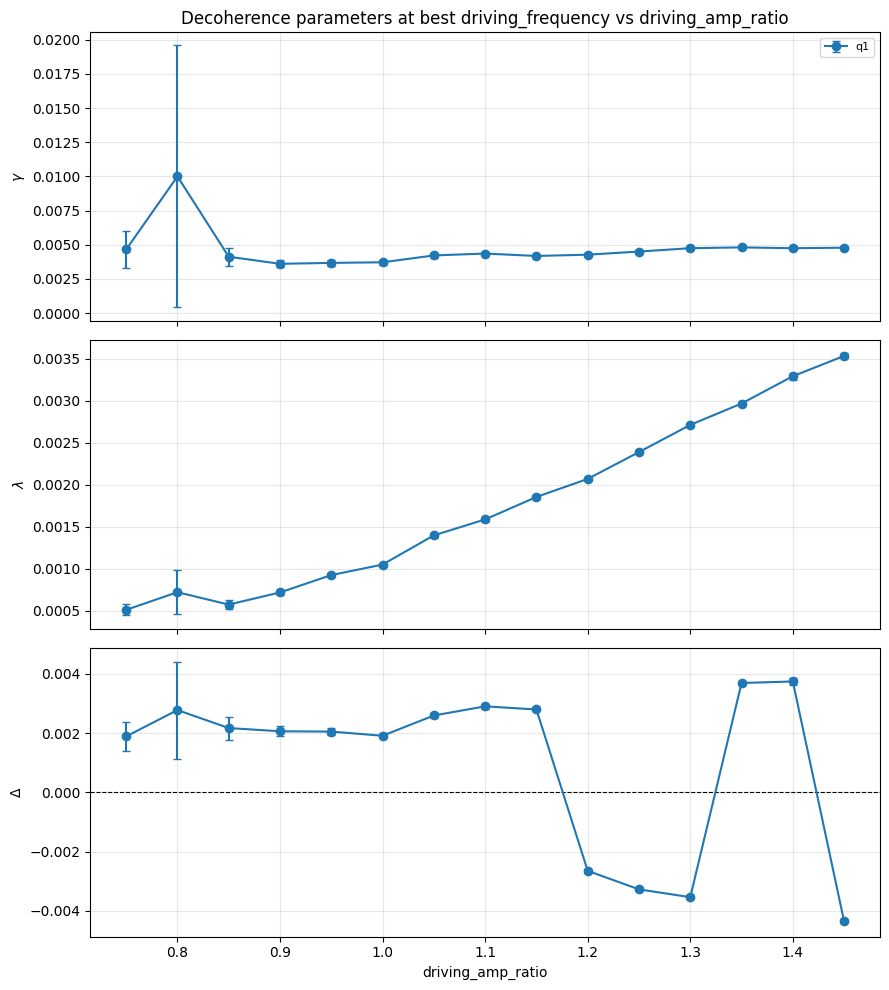

In [8]:
# --- (3) Decoherence params (gamma, lambda_, Delta) at best_freq_dec vs amp_ratio ---
fig3, axes3 = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
for q_idx, (qname, rows) in enumerate(agg.items()):
    marker = 'osDv^P*X'[q_idx % 8]
    color = f'C{q_idx}'
    amps, gamma, gamma_err, lam, lam_err, delta, delta_err = [], [], [], [], [], [], []
    for d in rows:
        res = d['res_dec']
        if res is None:
            continue
        amps.append(d['amp'])
        gamma.append(res['gamma'])
        gamma_err.append(res.get('gamma_err', np.nan))
        lam.append(res['lambda_'])
        lam_err.append(res.get('lambda_err', np.nan))
        delta.append(res['Delta'])
        delta_err.append(res.get('Delta_err', np.nan))
    if not amps:
        continue
    axes3[0].errorbar(amps, gamma, yerr=gamma_err, fmt=marker + '-', color=color,
                        capsize=3, label=qname)
    axes3[1].errorbar(amps, lam, yerr=lam_err, fmt=marker + '-', color=color,
                        capsize=3, label=qname)
    axes3[2].errorbar(amps, delta, yerr=delta_err, fmt=marker + '-', color=color,
                        capsize=3, label=qname)
axes3[0].set_ylabel(r'$\gamma$')
axes3[0].set_title('Decoherence parameters at best driving_frequency vs driving_amp_ratio')
axes3[0].grid(True, alpha=0.3)
axes3[0].legend(fontsize=8)
axes3[1].set_ylabel(r'$\lambda$')
axes3[1].grid(True, alpha=0.3)
axes3[2].set_ylabel(r'$\Delta$')
axes3[2].axhline(0, color='k', lw=0.8, ls='--')
axes3[2].set_xlabel('driving_amp_ratio')
axes3[2].grid(True, alpha=0.3)
fig3.tight_layout()
plt.show()

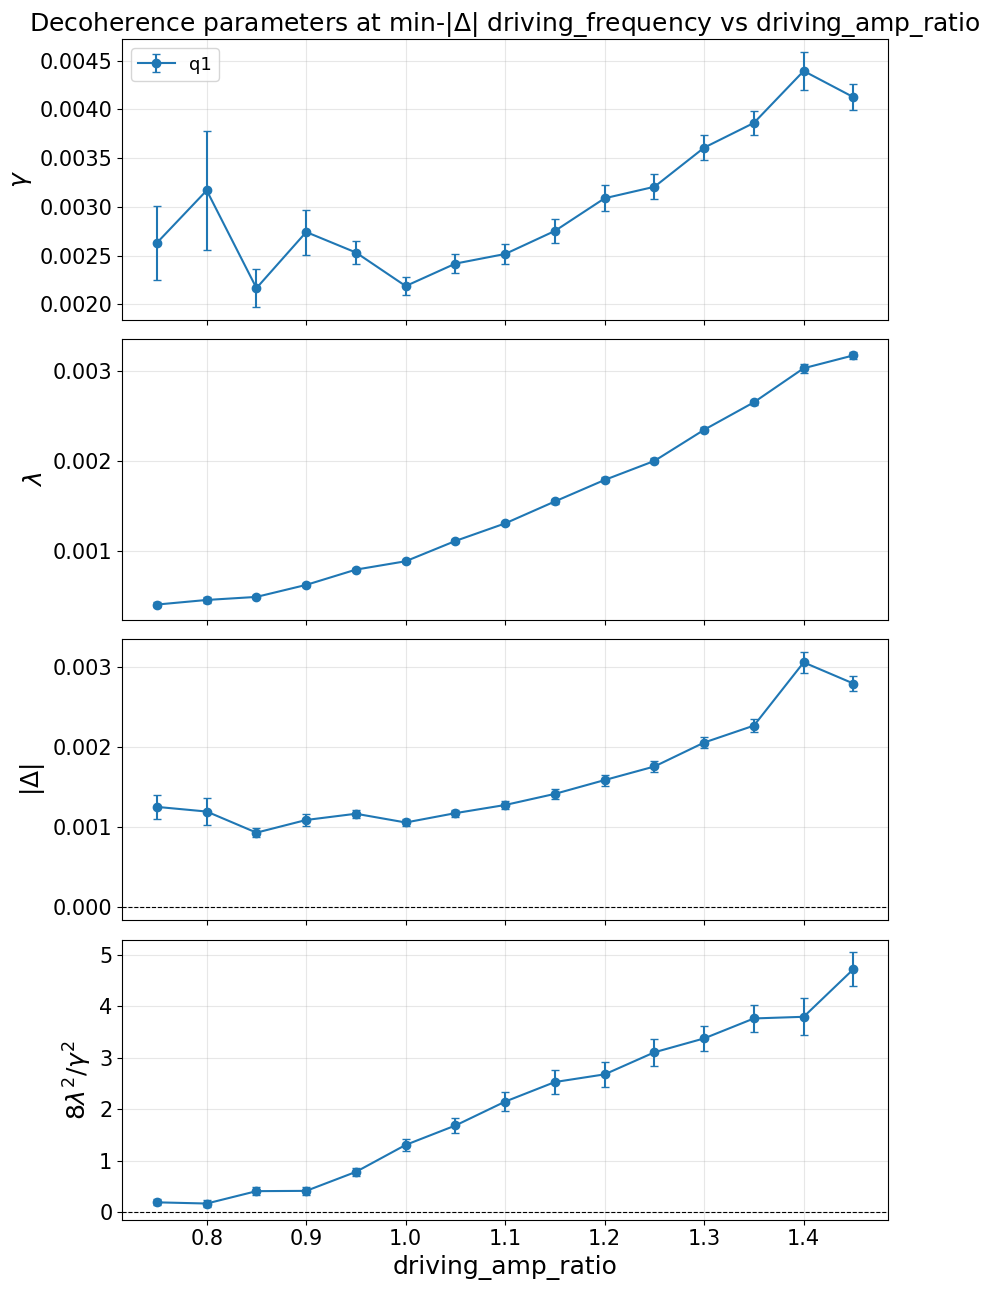

In [9]:
# --- (4) Decoherence params (gamma, lambda_, Delta) at freq with min |Delta| vs amp_ratio ---

def _best_freq_min_delta(per_freq):
    """Pick the driving_frequency with the smallest |Delta|."""
    valid = [(f, r) for f, r in per_freq.items()
             if r is not None and np.isfinite(r.get('Delta', np.inf))]
    if not valid:
        return None, None
    f_val, res = min(valid, key=lambda x: abs(x[1]['Delta']))
    return float(f_val), res


agg_delta = {}
for path, entry in all_results.items():
    amp = entry['driving_amp_ratio']
    if amp is None:
        continue
    for r in entry['results']:
        qname = r['qubit_name']
        f_dec_d, res_dec_d = _best_freq_min_delta(r['decoh'])
        agg_delta.setdefault(qname, []).append({
            'amp': amp,
            'f_dec': f_dec_d,
            'res_dec': res_dec_d,
        })

for qname, rows in agg_delta.items():
    rows.sort(key=lambda d: d['amp'])

LABEL_SIZE = 18
TITLE_SIZE = 18
TICK_SIZE = 15
LEGEND_SIZE = 13

fig4, axes4 = plt.subplots(4, 1, figsize=(9, 13), sharex=True)
for q_idx, (qname, rows) in enumerate(agg_delta.items()):
    marker = 'osDv^P*X'[q_idx % 8]
    color = f'C{q_idx}'
    amps, gamma, gamma_err, lam, lam_err, delta, delta_err = [], [], [], [], [], [], []
    for d in rows:
        res = d['res_dec']
        if res is None:
            continue
        amps.append(d['amp'])
        gamma.append(res['gamma'])
        gamma_err.append(res.get('gamma_err', np.nan))
        lam.append(res['lambda_'])
        lam_err.append(res.get('lambda_err', np.nan))
        delta.append(res['Delta'])
        delta_err.append(res.get('Delta_err', np.nan))
    if not amps:
        continue
    gamma_arr = np.array(gamma)
    lam_arr = np.array(lam)
    gamma_err_arr = np.array(gamma_err)
    lam_err_arr = np.array(lam_err)
    ratio = 8 * lam_arr**2 / gamma_arr**2
    # Propagate uncertainties: d(ratio)/ratio = 2*d(lam)/lam + 2*d(gamma)/gamma
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio_err = ratio * np.sqrt((2 * lam_err_arr / lam_arr)**2 + (2 * gamma_err_arr / gamma_arr)**2)
    axes4[0].errorbar(amps, gamma, yerr=gamma_err, fmt=marker + '-', color=color,
                      capsize=3, label=qname)
    axes4[1].errorbar(amps, lam, yerr=lam_err, fmt=marker + '-', color=color,
                      capsize=3, label=qname)
    axes4[2].errorbar(amps, np.abs(delta), yerr=delta_err, fmt=marker + '-', color=color,
                      capsize=3, label=qname)
    axes4[3].errorbar(amps, ratio, yerr=ratio_err, fmt=marker + '-', color=color,
                      capsize=3, label=qname)
axes4[0].set_ylabel(r'$\gamma$', fontsize=LABEL_SIZE)
axes4[0].set_title(r'Decoherence parameters at min-$|\Delta|$ driving_frequency vs driving_amp_ratio', fontsize=TITLE_SIZE)
axes4[0].grid(True, alpha=0.3)
axes4[0].legend(fontsize=LEGEND_SIZE)
axes4[0].tick_params(labelsize=TICK_SIZE)
axes4[1].set_ylabel(r'$\lambda$', fontsize=LABEL_SIZE)
axes4[1].grid(True, alpha=0.3)
axes4[1].tick_params(labelsize=TICK_SIZE)
axes4[2].set_ylabel(r'$|\Delta|$', fontsize=LABEL_SIZE)
axes4[2].axhline(0, color='k', lw=0.8, ls='--')
axes4[2].grid(True, alpha=0.3)
axes4[2].tick_params(labelsize=TICK_SIZE)
axes4[3].set_ylabel(r'$8\lambda^2/\gamma^2$', fontsize=LABEL_SIZE)
axes4[3].axhline(0, color='k', lw=0.8, ls='--')
axes4[3].set_xlabel('driving_amp_ratio', fontsize=LABEL_SIZE)
axes4[3].grid(True, alpha=0.3)
axes4[3].tick_params(labelsize=TICK_SIZE)
fig4.tight_layout()
plt.show()


## Convenience accessors

If you want the same variable names used by the plotting cells in
`view_single_raw.ipynb`, pick a file and unpack:

```python
entry                 = all_results[h5_file_paths[0]]
amp_ratio             = entry['driving_amp_ratio']
results               = entry['results']
qubit_data            = [r['sq_data']        for r in results]
rho_datasets          = [r['rho_ds']         for r in results]
hankel_diagnostics    = [r['hankel']         for r in results]
mdo_fit_results       = [r['mdo']            for r in results]
decoh_fit_results     = [r['decoh']          for r in results]
decoh_initial_guesses = [r['decoh_guesses']  for r in results]
```

Then any plotting cell from `view_single_raw.ipynb` can be pasted as-is.